In [94]:
import pandas as pd
import numpy as np

df = pd.read_csv('/kaggle/input/datasets/davidnagib/tweets-dataset/train.csv')

df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [96]:
df.drop('textID', axis = 1, inplace = True)
df.drop('selected_text', axis = 1, inplace = True)

In [97]:
df = df.dropna()

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27480 entries, 0 to 27480
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       27480 non-null  object
 1   sentiment  27480 non-null  object
dtypes: object(2)
memory usage: 644.1+ KB


In [99]:
from sklearn.preprocessing import LabelEncoder

import re

def preprocess_text(text):
    text = str(text)

    # remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # remove mentions (@user)
    text = re.sub(r'@\w+', '', text)

    # remove hashtags symbol only (#happy → happy)
    text = re.sub(r'#', '', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['clean_text'] = df['text'].apply(preprocess_text)


le = LabelEncoder()

df['sentiment_encoded'] = le.fit_transform(df['sentiment'])



df.head(10)

,text,sentiment,clean_text,sentiment_encoded
0,"I`d have responded, if I were going",neutral,"I`d have responded, if I were going",1
1,Sooo SAD I will miss you here in San Diego!!!,negative,Sooo SAD I will miss you here in San Diego!!!,0
2,my boss is bullying me...,negative,my boss is bullying me...,0
3,what interview! leave me alone,negative,what interview! leave me alone,0
4,"Sons of ****, why couldn`t they put them on t...",negative,"Sons of ****, why couldn`t they put them on th...",0
5,http://www.dothebouncy.com/smf - some shameles...,neutral,- some shameless plugging for the best Rangers...,1
6,2am feedings for the baby are fun when he is a...,positive,2am feedings for the baby are fun when he is a...,2
7,Soooo high,neutral,Soooo high,1
8,Both of you,neutral,Both of you,1
9,Journey!? Wow... u just became cooler. hehe....,positive,Journey!? Wow... u just became cooler. hehe......,2


In [100]:
from transformers import BertModel, BertTokenizer
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import Dense
import numpy as np


bert = BertModel.from_pretrained('/kaggle/input/datasets/abhishek/bert-base-uncased')
bert_embeddings = bert.embeddings.word_embeddings.weight.detach().numpy()
tokenizer = BertTokenizer.from_pretrained('/kaggle/input/datasets/abhishek/bert-base-uncased')
texts  = df['clean_text'].tolist()       # tokenizer expects list, not Series
labels = df['sentiment_encoded'].values  # .values gives NumPy array, needed for train_test_split

encodings = tokenizer(
    texts,
    padding=True,
    truncation=True,
    max_length=50,
    return_tensors='np'   # 'np' = NumPy arrays, compatible with TensorFlow/Keras
)

input_ids = encodings['input_ids']  # shape: (num_samples, 50)
                                    # each row = token IDs for one tweet
        

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: /kaggle/input/datasets/abhishek/bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [101]:
input_ids = encodings['input_ids'] # what it this ??

X_train, X_test, y_train, y_test = train_test_split(
    input_ids, 
    labels,
    test_size = 0.2,
    random_state = 42
)

In [102]:
def build_rnn():
    model = tf.keras.Sequential()
    # Embedding layer (BERT vocab size = 30522)
    model.add(tf.keras.layers.Embedding(
        input_dim=30522,
        output_dim=768,
        weights=[bert_embeddings],   # ← load pre-trained weights
        trainable=False,             # ← freeze them (or True to fine-tune)
        input_length=50
    ))
    model.add(tf.keras.layers.SimpleRNN(128))
    model.add(Dense(3, activation = 'softmax'))
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model
def build_lstm():
    model = tf.keras.Sequential()
    # Embedding layer (BERT vocab size = 30522)
    model.add(tf.keras.layers.Embedding(
        input_dim=30522,
        output_dim=768,
        weights=[bert_embeddings],   # ← load pre-trained weights
        trainable=False,             # ← freeze them (or True to fine-tune)
        input_length=50
    ))
    model.add(tf.keras.layers.LSTM(128))
    model.add(Dense(3, activation = 'softmax'))
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model
def build_gru():
    model = tf.keras.Sequential()
    # Embedding layer (BERT vocab size = 30522)
    model.add(tf.keras.layers.Embedding(
        input_dim=30522,
        output_dim=768,
        weights=[bert_embeddings],   # ← load pre-trained weights
        trainable=False,             # ← freeze them (or True to fine-tune)
        input_length=50
    ))
    model.add(tf.keras.layers.GRU(128))
    model.add(Dense(3, activation = 'softmax'))
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

In [103]:
models = {
    "RNN": build_rnn(),
    "LSTM": build_lstm(),
    "GRU": build_gru()
}
histories = {
    
}
accuracies = {
    
}

for name, model in models.items():
    print(f"\n Training {name} :- ")
    history = model.fit(
        X_train, y_train,
        epochs = 10,
        batch_size = 32,
        validation_split = 0.1,
        verbose = 1
    )
    loss, acc = model.evaluate(X_test, y_test)
    histories[name] = history
    accuracies[name] = acc


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



 Training RNN :- 
Epoch 1/10
619/619 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.3776 - loss: 1.1046 - val_accuracy: 0.4147 - val_loss: 1.0844
Epoch 2/10
619/619 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.3848 - loss: 1.0970 - val_accuracy: 0.4152 - val_loss: 1.0850
Epoch 3/10
619/619 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.3997 - loss: 1.0928 - val_accuracy: 0.4152 - val_loss: 1.0950
Epoch 4/10
619/619 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.3851 - loss: 1.0966 - val_accuracy: 0.4152 - val_loss: 1.0840
Epoch 5/10
619/619 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.3936 - loss: 1.0923 - val_accuracy: 0.4147 - val_loss: 1.0852
Epoch 6/10
619/619 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.3940 - loss: 1.0907 - val_accuracy: 0.4147 - val_loss: 1.0847
Epoch 7/10
619/619 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.3767 - loss: 1.1015 - val_accuracy: 0.4152 - val_loss: 1.0924
Epoch 8/10
619/619 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.409

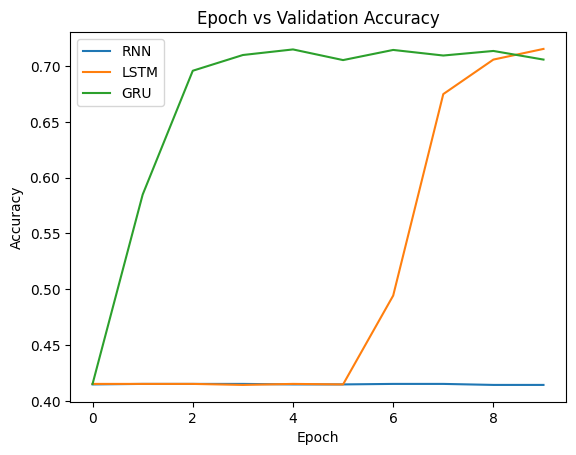

In [104]:
import matplotlib.pyplot as plt

plt.figure()

for name in histories:
    plt.plot(histories[name].history['val_accuracy'], label=name)

plt.title("Epoch vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [105]:
lengths = np.sum(input_ids != 0, axis=1)
bins = [0, 10, 20, 30, 40, 50]
from sklearn.metrics import accuracy_score

length_results = {}

for name, model in models.items():
    bucket_acc = []

    for i in range(len(bins)-1):
        mask = (lengths >= bins[i]) & (lengths < bins[i+1])

        if np.sum(mask) == 0:
            bucket_acc.append(0)
            continue

        preds = np.argmax(model.predict(input_ids[mask]), axis=1)
        acc = accuracy_score(labels[mask], preds)

        bucket_acc.append(acc)

    length_results[name] = bucket_acc

137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
241/241 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step
329/329 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step
241/241 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
241/241 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


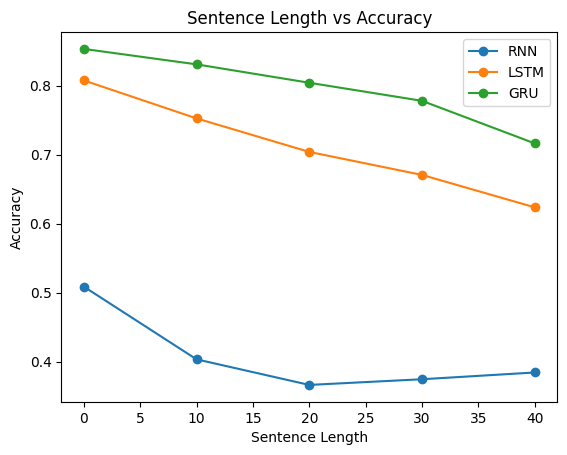

In [106]:
plt.figure()

for name in length_results:
    plt.plot(bins[:-1], length_results[name], marker='o', label=name)

plt.title("Sentence Length vs Accuracy")
plt.xlabel("Sentence Length")
plt.ylabel("Accuracy")
plt.legend()
plt.show()